In [1]:
# Compare the results of estimating uncertainty by adding in quadrature or not

In [39]:
import numpy as np
import rmgpy.tools.uncertainty
import rmgpy.chemkin
import matplotlib.pyplot as plt
%matplotlib inline

In [108]:
def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False

def get_n_heavy(species):
    return species.molecule[0].get_num_atoms() - np.sum([x.symbol == 'H' for x in species.molecule[0].atoms])

def get_n_groups(entry):
    groups = 0
    if 'GAV' not in entry.keys():
        return groups
    for key in entry['GAV'].keys():
        for group_entry in entry['GAV'][key]:
            groups += group_entry[1]
    return groups

def get_n_unique_groups(entry):
    groups = 0
    if 'GAV' not in entry.keys():
        return groups
    for key in entry['GAV'].keys():
        groups += len(entry['GAV'][key])
    return groups

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [ ]:
# Pick a reference library
ref_library = 'DFT_QCI_thermo'
ref_temperature = 1000.0

# load the uncertainty
original_uncertainty = np.load('thermo_chemkin_files/original_GAV_input_uncertainties.npy')
quadrature_uncertainty = np.load('thermo_chemkin_files/quadrature_GAV_input_uncertainties.npy')



In [ ]:
GAV_chemkin = 'thermo_chemkin_files/GAV.inp'
GAV_spec_dict = 'thermo_chemkin_files/GAV_species_dictionary.txt'


uncertainty = rmgpy.tools.uncertainty.Uncertainty()
uncertainty.load_model(GAV_chemkin, GAV_spec_dict)
uncertainty.load_database(thermo_libraries=[], kinetics_families='none')

# uncertainty.extract_sources_from_model()  # should give same number of groups both before and after

In [72]:
# Compute the GAV error for this reference library
species_list_ref, _ = rmgpy.chemkin.load_chemkin_file(f'thermo_chemkin_files/{ref_library}.inp', f'thermo_chemkin_files/{ref_library}_species_dictionary.txt')

GAV_species_list = []
GAV_original_uncertainty_est = np.zeros(len(species_list_ref))
GAV_quadrature_uncertainty_est = np.zeros(len(species_list_ref))
for i in range(len(species_list_ref)):
    j = get_i_thing(species_list_ref[i], uncertainty.species_list)
    GAV_original_uncertainty_est[i] = original_uncertainty[j]
    GAV_quadrature_uncertainty_est[i] = quadrature_uncertainty[j]
    GAV_species_list.append(uncertainty.species_list[j])


GAV_Gs = np.array([x.get_free_energy(ref_temperature) for x in GAV_species_list])
ref_Gs = np.array([x.get_free_energy(ref_temperature) for x in species_list_ref])
GAV_error = np.abs(GAV_Gs - ref_Gs) / 4184  # convert J/mol to kcal/mol

In [64]:
# get the number of heavy atoms

n_heavy_atoms = [get_n_heavy(x) for x in GAV_species_list]

# this includes repeats as separate groups
n_groups = [get_n_groups(uncertainty.database.thermo.extract_source_from_comments(x)) for x in GAV_species_list]

n_unique_groups = [get_n_unique_groups(uncertainty.database.thermo.extract_source_from_comments(x)) for x in GAV_species_list]

## Plot GAV Error vs. n heavy atoms

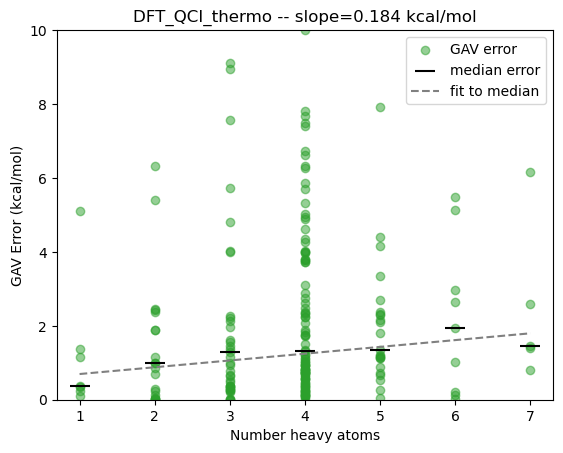

In [109]:
plt.scatter(n_heavy_atoms, GAV_error, alpha=0.5, label='GAV error', color=colors[2])


# Fit a line through the median value for each set falling under a given number of heavy atoms
# too many outliers for mean to work here
medians = np.zeros(max(n_heavy_atoms)) + np.nan
xs = np.arange(len(medians)) + 1
for j in range(len(medians)):
    subset = [GAV_error[i] for i in range(len(GAV_species_list)) if n_heavy_atoms[i] == xs[j]]
    medians[j] = np.nanmedian(np.abs(subset))


plt.scatter(xs, medians, marker='_', color='black', s=200, label='median error')

xs = xs[~np.isnan(medians)]
medians = medians[~np.isnan(medians)]
m, b = np.polyfit(xs, medians, deg=1)
plt.plot(xs, b + m * xs, color='grey', linestyle='dashed', label='fit to median')

plt.title(ref_library + f' -- slope={m:0.3f} kcal/mol')
plt.xlabel('Number heavy atoms')
plt.ylabel('GAV Error (kcal/mol)')
plt.ylim([0, 10.0])
plt.legend()

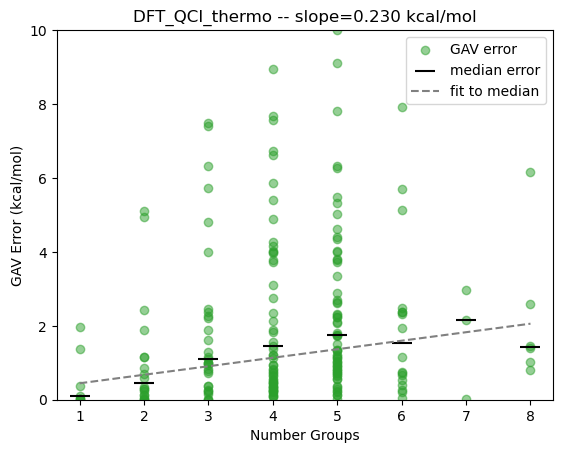

In [110]:
plt.scatter(n_groups, GAV_error, alpha=0.5, label='GAV error', color=colors[2])


# Fit a line through the median value for each set falling under a given number of heavy atoms
# too many outliers for mean to work here
medians = np.zeros(max(n_groups)) + np.nan
xs = np.arange(len(medians)) + 1
for j in range(len(medians)):
    subset = [GAV_error[i] for i in range(len(GAV_species_list)) if n_groups[i] == xs[j]]
    medians[j] = np.nanmedian(np.abs(subset))


plt.scatter(xs, medians, marker='_', color='black', s=200, label='median error')

xs = xs[~np.isnan(medians)]
medians = medians[~np.isnan(medians)]
m, b = np.polyfit(xs, medians, deg=1)
plt.plot(xs, b + m * xs, color='grey', linestyle='dashed', label='fit to median')

plt.title(ref_library + f' -- slope={m:0.3f} kcal/mol')
plt.xlabel('Number Groups')
plt.ylabel('GAV Error (kcal/mol)')
plt.ylim([0, 10.0])
plt.legend()

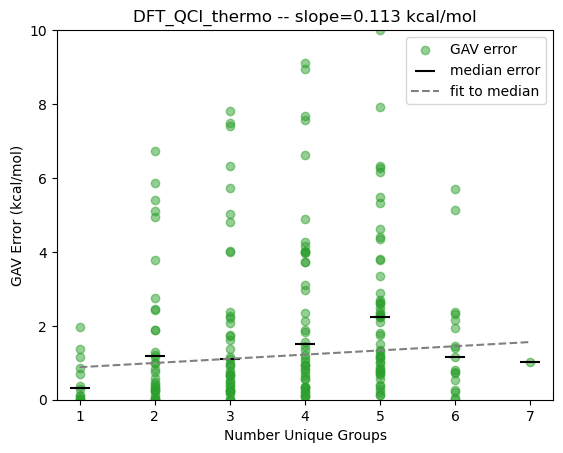

In [112]:
plt.scatter(n_unique_groups, GAV_error, alpha=0.5, label='GAV error', color=colors[2])

# Fit a line through the median value for each set falling under a given number of heavy atoms
# too many outliers for mean to work here
medians = np.zeros(max(n_unique_groups)) + np.nan
xs = np.arange(len(medians)) + 1
for j in range(len(medians)):
    subset = [GAV_error[i] for i in range(len(GAV_species_list)) if n_unique_groups[i] == xs[j]]
    medians[j] = np.nanmedian(np.abs(subset))


plt.scatter(xs, medians, marker='_', color='black', s=200, label='median error')

xs = xs[~np.isnan(medians)]
medians = medians[~np.isnan(medians)]
m, b = np.polyfit(xs, medians, deg=1)
plt.plot(xs, b + m * xs, color='grey', linestyle='dashed', label='fit to median')

plt.title(ref_library + f' -- slope={m:0.3f} kcal/mol')
plt.xlabel('Number Unique Groups')
plt.ylabel('GAV Error (kcal/mol)')
plt.ylim([0, 10.0])
plt.legend()


Text(0, 0.5, 'Uncertainty Estimate kcal/mol')

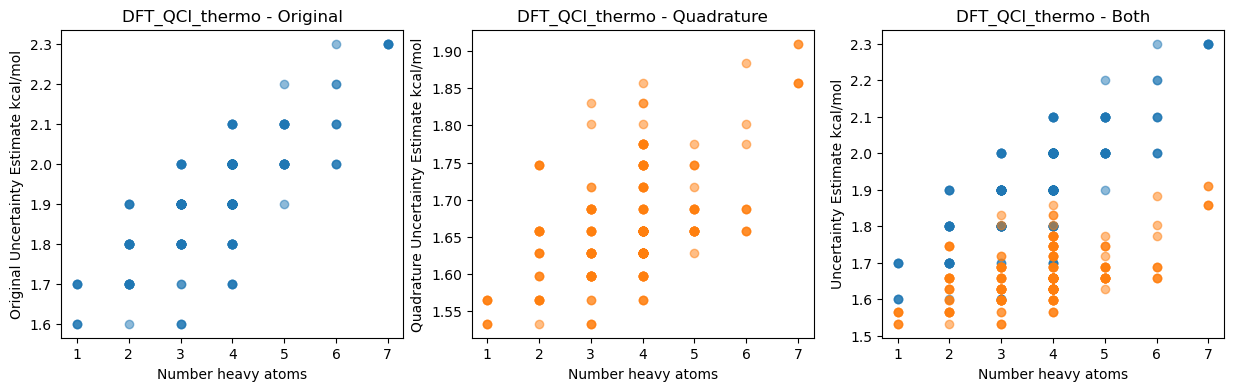

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
axes[0].scatter(n_heavy_atoms, GAV_original_uncertainty_est, alpha=0.5, color=colors[0])
axes[0].set_title(ref_library + ' - Original')
axes[0].set_xlabel('Number heavy atoms')
axes[0].set_ylabel('Original Uncertainty Estimate kcal/mol')

axes[1].scatter(n_heavy_atoms, GAV_quadrature_uncertainty_est, alpha=0.5, color=colors[1])
axes[1].set_title(ref_library + ' - Quadrature')
axes[1].set_xlabel('Number heavy atoms')
axes[1].set_ylabel('Quadrature Uncertainty Estimate kcal/mol')

axes[2].scatter(n_heavy_atoms, GAV_original_uncertainty_est, alpha=0.5, color=colors[0])
axes[2].scatter(n_heavy_atoms, GAV_quadrature_uncertainty_est, alpha=0.5, color=colors[1])
axes[2].set_title(ref_library + ' - Both')
axes[2].set_xlabel('Number heavy atoms')
axes[2].set_ylabel('Uncertainty Estimate kcal/mol')

Text(0, 0.5, 'Uncertainty Estimate kcal/mol')

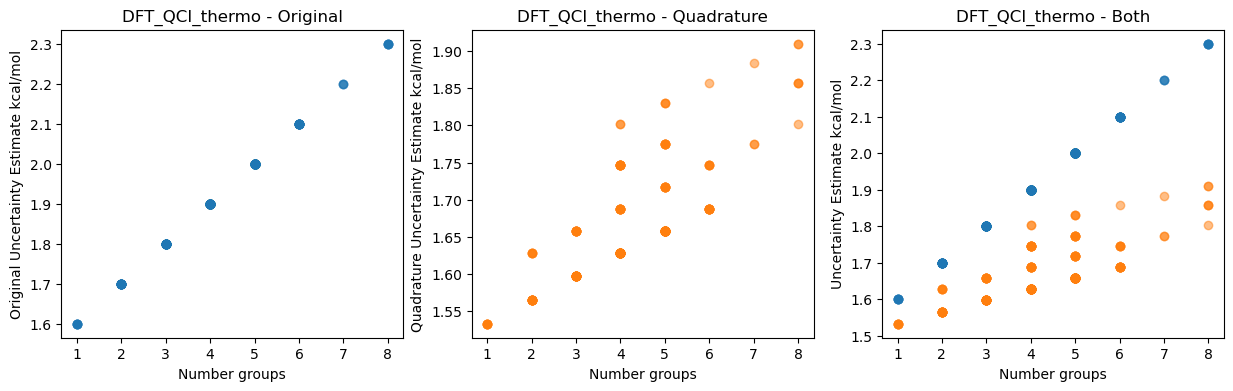

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
axes[0].scatter(n_groups, GAV_original_uncertainty_est, alpha=0.5, color=colors[0])
axes[0].set_title(ref_library + ' - Original')
axes[0].set_xlabel('Number groups')
axes[0].set_ylabel('Original Uncertainty Estimate kcal/mol')

axes[1].scatter(n_groups, GAV_quadrature_uncertainty_est, alpha=0.5, color=colors[1])
axes[1].set_title(ref_library + ' - Quadrature')
axes[1].set_xlabel('Number groups')
axes[1].set_ylabel('Quadrature Uncertainty Estimate kcal/mol')

axes[2].scatter(n_groups, GAV_original_uncertainty_est, alpha=0.5, color=colors[0])
axes[2].scatter(n_groups, GAV_quadrature_uncertainty_est, alpha=0.5, color=colors[1])
axes[2].set_title(ref_library + ' - Both')
axes[2].set_xlabel('Number groups')
axes[2].set_ylabel('Uncertainty Estimate kcal/mol')

Text(0, 0.5, 'Uncertainty Estimate kcal/mol')

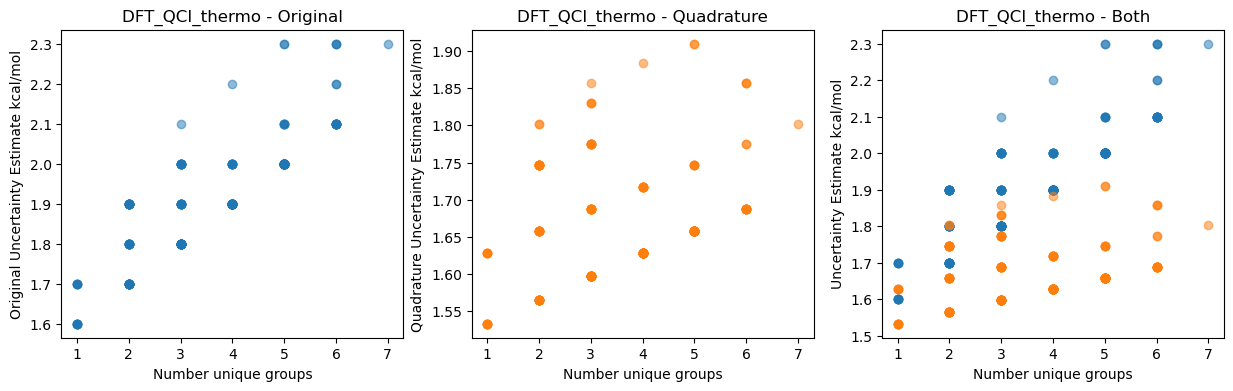

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
axes[0].scatter(n_unique_groups, GAV_original_uncertainty_est, alpha=0.5, color=colors[0])
axes[0].set_title(ref_library + ' - Original')
axes[0].set_xlabel('Number unique groups')
axes[0].set_ylabel('Original Uncertainty Estimate kcal/mol')

axes[1].scatter(n_unique_groups, GAV_quadrature_uncertainty_est, alpha=0.5, color=colors[1])
axes[1].set_title(ref_library + ' - Quadrature')
axes[1].set_xlabel('Number unique groups')
axes[1].set_ylabel('Quadrature Uncertainty Estimate kcal/mol')

axes[2].scatter(n_unique_groups, GAV_original_uncertainty_est, alpha=0.5, color=colors[0])
axes[2].scatter(n_unique_groups, GAV_quadrature_uncertainty_est, alpha=0.5, color=colors[1])
axes[2].set_title(ref_library + ' - Both')
axes[2].set_xlabel('Number unique groups')
axes[2].set_ylabel('Uncertainty Estimate kcal/mol')